In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [6]:
yfObj = yf.Ticker('AAPL')
data = yfObj.history(start='2010-01-01', end='2011-01-01')
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-01-04 00:00:00-05:00,6.444462,6.476770,6.412757,6.461975,493729600,0.0,0.0
2010-01-05 00:00:00-05:00,6.479793,6.509685,6.439029,6.473150,601904800,0.0,0.0
2010-01-06 00:00:00-05:00,6.473146,6.498812,6.363540,6.370183,552160000,0.0,0.0
2010-01-07 00:00:00-05:00,6.393738,6.401287,6.312212,6.358409,477131200,0.0,0.0
2010-01-08 00:00:00-05:00,6.349954,6.401285,6.312513,6.400681,447610800,0.0,0.0
...,...,...,...,...,...,...,...
2010-12-27 00:00:00-05:00,9.748372,9.826576,9.708213,9.803628,249816000,0.0,0.0
2010-12-28 00:00:00-05:00,9.840765,9.863412,9.815101,9.827480,175924000,0.0,0.0
2010-12-29 00:00:00-05:00,9.850130,9.857075,9.816312,9.822049,163139200,0.0,0.0


In [7]:
P = 14
# Drop extra columns for paucity
data.drop(['Open', 'High', 'Low', 'Volume', 'Dividends', 
    'Stock Splits'], inplace=True, axis=1)
data['diff_close'] = data['Close'] - data['Close'].shift(1)
data['gain'] = np.where(data['diff_close']>0, data['diff_close'], 0)
data['loss'] = np.where(data['diff_close']<0, np.abs(data['diff_close']), 0)
data.head()

,Close,diff_close,gain,loss
Date,,,,
2010-01-04 00:00:00-05:00,6.461975,NaN,0.000000,0.000000
2010-01-05 00:00:00-05:00,6.473150,0.011175,0.011175,0.000000
2010-01-06 00:00:00-05:00,6.370183,-0.102967,0.000000,0.102967
2010-01-07 00:00:00-05:00,6.358409,-0.011773,0.000000,0.011773
2010-01-08 00:00:00-05:00,6.400681,0.042272,0.042272,0.000000


In [8]:
data[['init_avg_gain', 'init_avg_loss']] = data[
    ['gain', 'loss']].rolling(P).mean()
data.iloc[10:15]


,Close,diff_close,gain,loss,init_avg_gain,init_avg_loss
Date,,,,,,
2010-01-19 00:00:00-05:00,6.493077,0.275075,0.275075,0.000000,NaN,NaN
2010-01-20 00:00:00-05:00,6.393132,-0.099945,0.000000,0.099945,NaN,NaN
2010-01-21 00:00:00-05:00,6.282619,-0.110513,0.000000,0.110513,NaN,NaN
2010-01-22 00:00:00-05:00,5.971009,-0.311610,0.000000,0.311610,0.029785,0.064854
2010-01-25 00:00:00-05:00,6.131645,0.160636,0.160636,0.000000,0.041259,0.064854


In [9]:
avg_gain = np.zeros(len(data))
avg_loss = np.zeros(len(data))
for i, _row in enumerate(data.iterrows()):
    row = _row[1]
    if i < P - 1:
        last_row = row.copy()
        continue
    elif i == P-1:
        avg_gain[i] += row['init_avg_gain']
        avg_loss[i] += row['init_avg_loss']
    else:
        avg_gain[i] += ((P - 1) * avg_gain[i-1] + row['gain']) / P
        avg_loss[i] += ((P - 1) * avg_loss[i-1] + row['loss']) / P
        
    last_row = row.copy()
    
data['avg_gain'] = avg_gain
data['avg_loss'] = avg_loss
data.tail()


,Close,diff_close,gain,loss,init_avg_gain,init_avg_loss,avg_gain,avg_loss
Date,,,,,,,,
2010-12-27 00:00:00-05:00,9.803628,0.032613,0.032613,0.000000,0.024372,0.014602,0.037433,0.022440
2010-12-28 00:00:00-05:00,9.827480,0.023852,0.023852,0.000000,0.026076,0.010418,0.036463,0.020837
2010-12-29 00:00:00-05:00,9.822049,-0.005431,0.000000,0.005431,0.020037,0.010806,0.033859,0.019737
2010-12-30 00:00:00-05:00,9.772826,-0.049223,0.000000,0.049223,0.020037,0.011626,0.031440,0.021843
2010-12-31 00:00:00-05:00,9.739614,-0.033212,0.000000,0.033212,0.018312,0.013998,0.029195,0.022655


In [10]:
data['RS'] = data['avg_gain'] / data['avg_loss']
data['RSI'] = 100 - 100 / (1 + data['RS'])
data.tail()


,Close,diff_close,gain,loss,init_avg_gain,init_avg_loss,avg_gain,avg_loss,RS,RSI
Date,,,,,,,,,,
2010-12-27 00:00:00-05:00,9.803628,0.032613,0.032613,0.000000,0.024372,0.014602,0.037433,0.022440,1.668133,62.520607
2010-12-28 00:00:00-05:00,9.827480,0.023852,0.023852,0.000000,0.026076,0.010418,0.036463,0.020837,1.749896,63.634991
2010-12-29 00:00:00-05:00,9.822049,-0.005431,0.000000,0.005431,0.020037,0.010806,0.033859,0.019737,1.715501,63.174384
2010-12-30 00:00:00-05:00,9.772826,-0.049223,0.000000,0.049223,0.020037,0.011626,0.031440,0.021843,1.439370,59.005809
2010-12-31 00:00:00-05:00,9.739614,-0.033212,0.000000,0.033212,0.018312,0.013998,0.029195,0.022655,1.288651,56.306139


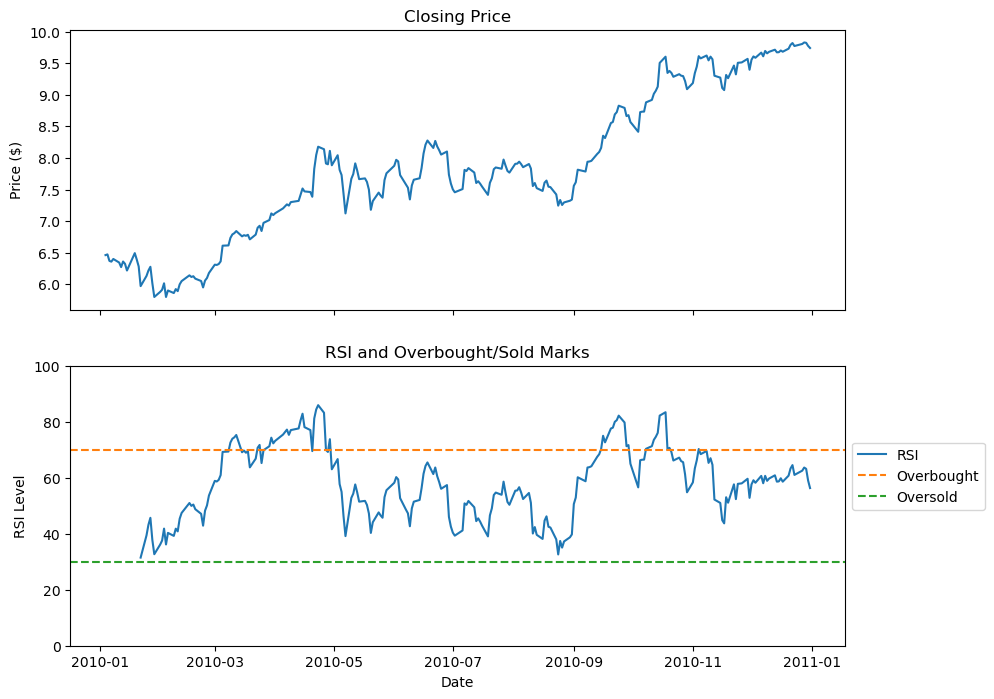

In [12]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(2, figsize=(10, 8), sharex=True)
ax[0].plot(data['Close'], label='Closing Price')
ax[0].set_ylabel('Price ($)')
ax[0].set_title('Closing Price')
ax[1].plot(data['RSI'], label='RSI')
ax[1].axhline(70, label='Overbought', color=colors[1], linestyle='--')
ax[1].axhline(30, label='Oversold', color=colors[2], linestyle='--')
ax[1].set_title('RSI and Overbought/Sold Marks')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('RSI Level')
ax[1].set_ylim([0, 100])
ax[1].legend(bbox_to_anchor=[1, 0.75])
plt.show()

In [13]:
def calcRSI(data, P=14):
  data['diff_close'] = data['Close'] - data['Close'].shift(1)
  data['gain'] = np.where(data['diff_close']>0, 
    data['diff_close'], 0)
  data['loss'] = np.where(data['diff_close']<0,
    np.abs(data['diff_close']), 0)
  data[['init_avg_gain', 'init_avg_loss']] = data[
    ['gain', 'loss']].rolling(P).mean()
  avg_gain = np.zeros(len(data))
  avg_loss = np.zeros(len(data))
  
  for i, _row in enumerate(data.iterrows()):
    row = _row[1]
    if i < P - 1:
      last_row = row.copy()
      continue
    elif i == P-1:
      avg_gain[i] += row['init_avg_gain']
      avg_loss[i] += row['init_avg_loss']
    else:
      avg_gain[i] += ((P - 1) * avg_gain[i-1] + row['gain']) / P
      avg_loss[i] += ((P - 1) * avg_loss[i-1] + row['loss']) / P
    last_row = row.copy()
  data['avg_gain'] = avg_gain
  data['avg_loss'] = avg_loss
  data['RS'] = data['avg_gain'] / data['avg_loss']
  data['RSI'] = 100 - 100 / (1 + data['RS'])
  return data

In [14]:
# Standard Mean Reversion
def RSIReversionStrategy(data, P=14, long_level=30, short_level=70,
  centerline=50, shorts=True):
  '''
  Goes long when RSI < long level, sells when the value crosses the
  centerline.
  Goes short when RSI > short level, covers when it crosses the
  centerline.
  '''
  df = calcRSI(data, P=P)
  df['position'] = np.nan
  df['position'] = np.where(df['RSI']<long_level, 1, df['position'])
  if shorts:
    df['position'] = np.where(df['RSI']>short_level, -1,
      df['position'])
  if centerline is not None:
    # Exit when RSI crosses sell_level
    _sell_level = df['RSI'] - centerline
    df['cross_sell_level'] = _sell_level.shift(1) / _sell_level
    df['position'] = np.where(df['cross_sell_level']<0, 0,   
      df['position'])
  else:
    df['position'] = np.where(df['RSI']>=short_level, 0,  
      df['position'])
  
  df['position'] = df['position'].ffill().fillna(0)
  
  return calcReturns(df)
def calcReturns(df):
  # Helper function to avoid repeating too much code
  df['returns'] = df['Close'] / df['Close'].shift(1)
  df['log_returns'] = np.log(df['returns'])
  df['strat_returns'] = df['position'].shift(1) * df['returns']
  df['strat_log_returns'] = df['position'].shift(1) * df['log_returns']
  df['cum_returns'] = np.exp(df['log_returns'].cumsum()) - 1
  df['strat_cum_returns'] = np.exp(
    df['strat_log_returns'].cumsum()) - 1
  df['peak'] = df['cum_returns'].cummax()
  df['strat_peak'] = df['strat_cum_returns'].cummax()
  return df

In [15]:
ticker = 'MSFT'
start = '2010-01-01'
end = '2020-12-31'
yfObj = yf.Ticker(ticker)
data = yfObj.history(start=start, end=end)
# Drop unused columns to keep things simple
data.drop(['Open', 'High', 'Low', 'Volume', 'Dividends',
  'Stock Splits'], inplace=True, axis=1)

data

,Close
Date,
2010-01-04 00:00:00-05:00,23.389399
2010-01-05 00:00:00-05:00,23.396957
2010-01-06 00:00:00-05:00,23.253368
2010-01-07 00:00:00-05:00,23.011543
2010-01-08 00:00:00-05:00,23.170250
...,...
2020-12-23 00:00:00-05:00,214.455399
2020-12-24 00:00:00-05:00,216.134033
2020-12-28 00:00:00-05:00,218.278397


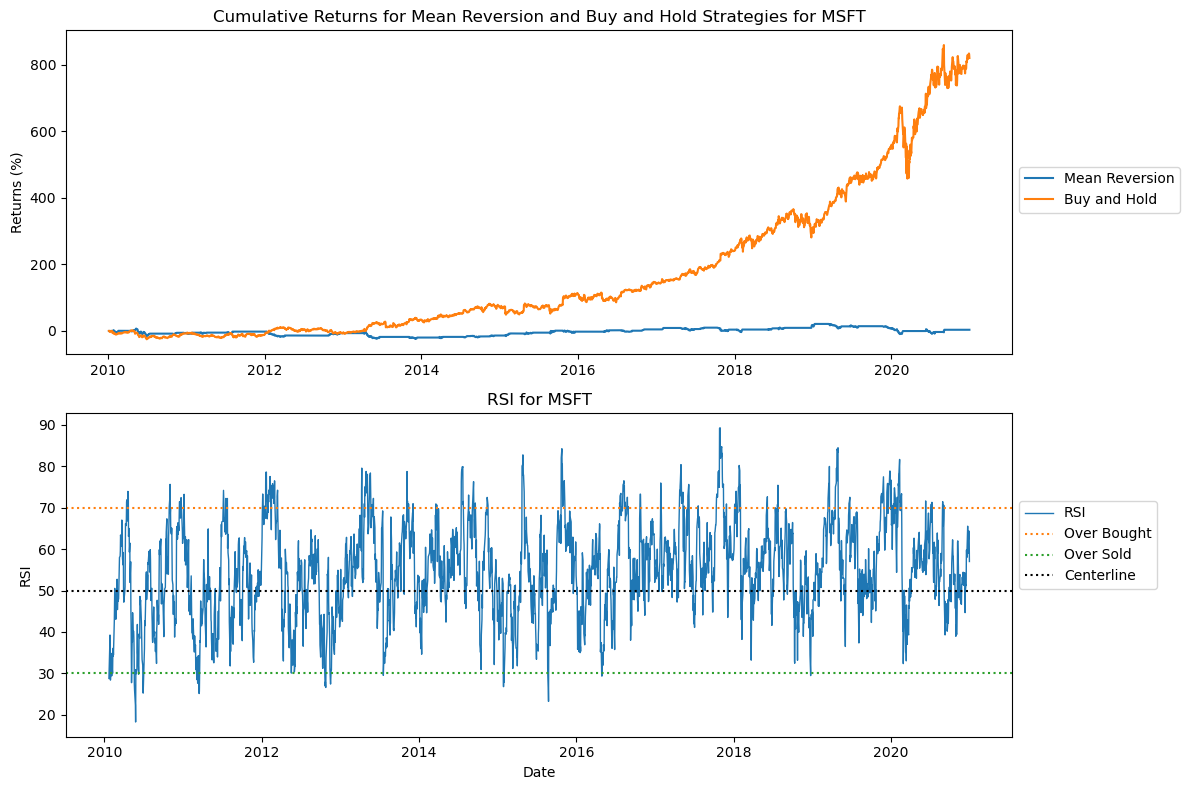

In [16]:
df_rev = RSIReversionStrategy(data.copy())
# Plot results
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(2, figsize=(12, 8))
ax[0].plot(df_rev['strat_cum_returns']*100, label='Mean Reversion')
ax[0].plot(df_rev['cum_returns']*100, label='Buy and Hold')
ax[0].set_ylabel('Returns (%)')
ax[0].set_title('Cumulative Returns for Mean Reversion and' +
  f' Buy and Hold Strategies for {ticker}')
ax[0].legend(bbox_to_anchor=[1, 0.6])
ax[1].plot(df_rev['RSI'], label='RSI', linewidth=1)
ax[1].axhline(70, label='Over Bought', color=colors[1], linestyle=':')
ax[1].axhline(30, label='Over Sold', color=colors[2], linestyle=':')
ax[1].axhline(50, label='Centerline', color='k', linestyle=':')
ax[1].set_ylabel('RSI')
ax[1].set_xlabel('Date')
ax[1].set_title(f'RSI for {ticker}')
ax[1].legend(bbox_to_anchor=[1, 0.75])
plt.tight_layout()
plt.show()


In [22]:
def getStratStats(log_returns: pd.Series, 
  risk_free_rate: float = 0.02):
  stats = {}
  # Total Returns
  stats['tot_returns'] = np.exp(log_returns.sum()) - 1
  # Mean Annual Returns
  stats['annual_returns'] = np.exp(log_returns.mean() * 252) - 1
  # Annual Volatility
  stats['annual_volatility'] = log_returns.std() * np.sqrt(252)
  # Sharpe Ratio
  stats['sharpe_ratio'] = (stats['annual_returns'] - 
    risk_free_rate) / stats['annual_volatility']
  # Max Drawdown
  cum_returns = log_returns.cumsum() - 1
  peak = cum_returns.cummax()
  drawdown = peak - cum_returns
  stats['max_drawdown'] = drawdown.max()
  # Max Drawdown Duration
  strat_dd = drawdown[drawdown==0]
  strat_dd_diff = strat_dd.index[1:] - strat_dd.index[:-1]
  strat_dd_days = strat_dd_diff.map(lambda x: x.days).values
  strat_dd_days = np.hstack([strat_dd_days,
    (drawdown.index[-1] - strat_dd.index[-1]).days])
  stats['max_drawdown_duration'] = strat_dd_days.max()
  return stats


In [23]:
stats_bh = getStratStats(df_rev['log_returns'])
stats_rev = getStratStats(df_rev['strat_log_returns'])
stats_df = pd.DataFrame()
stats_df = pd.concat([
  pd.DataFrame(stats_bh, index=['Buy and Hold']),
  pd.DataFrame(stats_rev, index=['RSI Mean Reversion'])
])
stats_df

,tot_returns,annual_returns,annual_volatility,sharpe_ratio,max_drawdown,max_drawdown_duration
Buy and Hold,8.196294,0.223938,0.253990,0.802936,0.329050,652
RSI Mean Reversion,0.036071,0.003232,0.125181,-0.133947,0.335529,2457


In [24]:
# RSI2
def RSI2Strategy(data, P=2, SMA1=200, SMA2=5, long_level=10,
  short_level=90):
  '''
  Short-term RSI strategy based on 2-period RSI to find mean   
  reversions within a larger trend.
  Long when price > SMA1 and RSI > long_level 
    -> exit when price > SMA2
  Short when price < SMA1 and RSI < short_level 
    -> exit when price < SMA2
  '''
  df = calcRSI(data, P=P)
  df['SMA1'] = df['Close'].rolling(SMA1).mean()
  df['SMA2'] = df['Close'].rolling(SMA2).mean()
  position = np.zeros(df.shape[0])
  position[:] = np.nan
  # Enter long positions
  position = np.where(
    (df['RSI']<long_level) & (df['Close']>df['SMA1']), 1, position)
  # Enter short positions
  position = np.where(
    (df['RSI']>short_level) & (df['Close']<df['SMA1']), 
      -1, position)
  # Loop to add exits
  for i, _row in enumerate(df.iterrows()):
    row = _row[1]
    if np.isnan(row['SMA1']):
      position[i] = 0
      continue
    # Exit positions based on SMA2, else hold
    if position[i-1] == 1:
      if row['Close'] > row['SMA2']:
        position[i] = 0
      else:
        position[i] = 1
    elif position[i-1] == -1:
      if row['Close'] < row['SMA2']:
        position[i] = 0
      else:
        position[i] = -1
  df['position'] = position
  df['position'] = df['position'].fillna(0)
  
  return calcReturns(df)

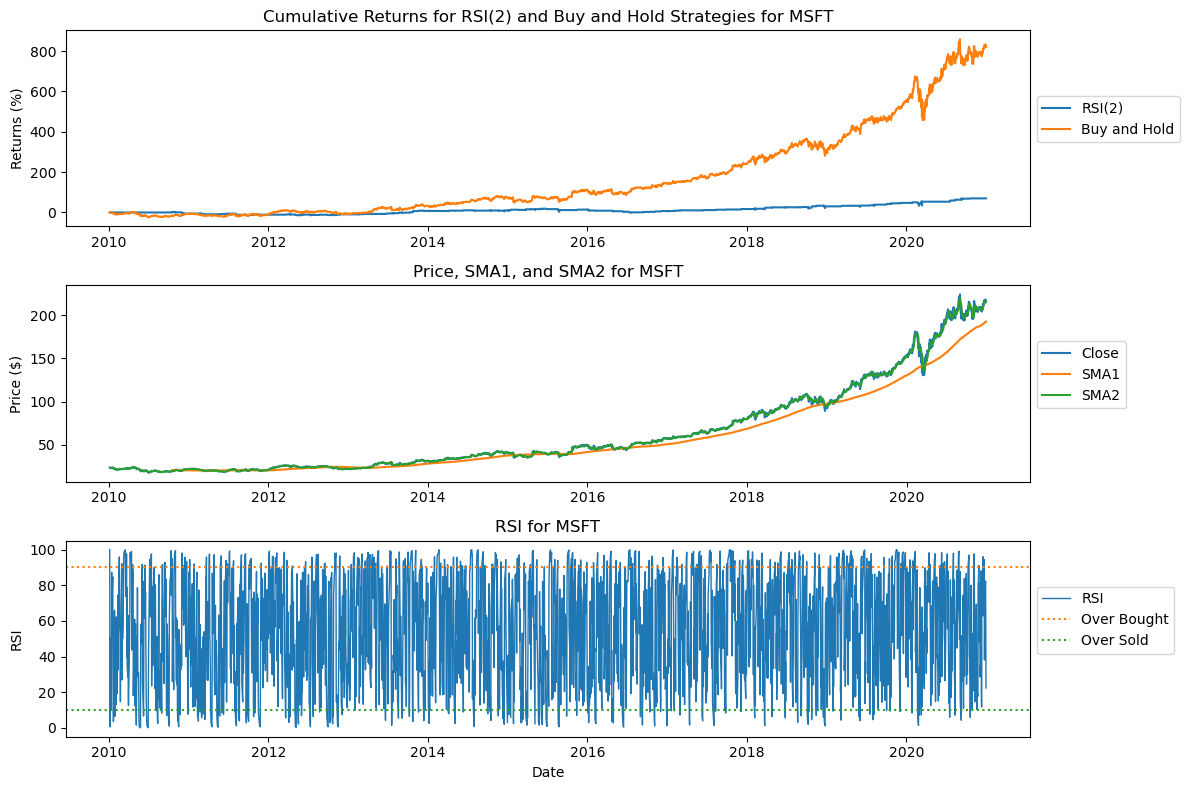

In [25]:
df_rsi2 = RSI2Strategy(data.copy())
# Plot results
fig, ax = plt.subplots(3, figsize=(12, 8))
ax[0].plot(df_rsi2['strat_cum_returns']*100, label='RSI(2)')
ax[0].plot(df_rsi2['cum_returns']*100, label='Buy and Hold')
ax[0].set_ylabel('Returns (%)')
ax[0].set_title('Cumulative Returns for RSI(2) and' +
  f' Buy and Hold Strategies for {ticker}')
ax[0].legend(bbox_to_anchor=[1, 0.7])
ax[1].plot(df_rsi2['Close'], label='Close')
ax[1].plot(df_rsi2['SMA1'], label='SMA1')
ax[1].plot(df_rsi2['SMA2'], label='SMA2')
ax[1].set_ylabel('Price ($)')
ax[1].set_title(f'Price, SMA1, and SMA2 for {ticker}')
ax[1].legend(bbox_to_anchor=[1, 0.75])
ax[2].plot(df_rsi2['RSI'], label='RSI', linewidth=1)
ax[2].axhline(90, label='Over Bought', color=colors[1], linestyle=':')
ax[2].axhline(10, label='Over Sold', color=colors[2], linestyle=':')
ax[2].set_ylabel('RSI')
ax[2].set_xlabel('Date')
ax[2].set_title(f'RSI for {ticker}')
ax[2].legend(bbox_to_anchor=[1, 0.8])
plt.tight_layout()
plt.show()

In [26]:
stats_bh = getStratStats(df_rsi2['log_returns'])
stats_rsi2 = getStratStats(df_rsi2['strat_log_returns'])
stats_df = pd.DataFrame()
stats_df = pd.concat([
  pd.DataFrame(stats_bh, index=['Buy and Hold']),
  pd.DataFrame(stats_rsi2, index=['RSI(2)'])
])
stats_df

,tot_returns,annual_returns,annual_volatility,sharpe_ratio,max_drawdown,max_drawdown_duration
Buy and Hold,8.196294,0.223938,0.253990,0.802936,0.329050,652
RSI(2),0.698529,0.049430,0.119153,0.246994,0.191461,1093


In [33]:
# Momentum Strategy
def RSIMomentumStrategy(data, P=14, centerline=50, 
  upper=70, lower=30, shorts=True):
  '''
  Buy when RSI crosses above the centerline, sell if it breaks above 
  the upper threshold then drops below it again or if it goes below 
  the centerline. 
  Short if it drops below the centerline and cover if it breaks 
  below the lower threshold and then above it, or above the 
  centerline.
  '''
  df = calcRSI(data, P=P)
  position = np.zeros(df.shape[0])
  for i, _row in enumerate(df.iterrows()):
    row = _row[1]
    if np.isnan(row['RSI']):
      last_row = row.copy()
      continue
    if row['RSI'] > centerline and last_row['RSI'] < centerline:
      # Buy if no position
      if position[i-1] != 1:
        position[i] = 1
    elif row['RSI'] > centerline and position[i-1] == 1:
      # Check if value has retraced
      if last_row['RSI'] > upper and row['RSI'] < upper:
        position[i] = 0
      else:
        position[i] = 1
    elif position[i-1] == 1 and row['RSI'] < centerline:
      if shorts:
        position[i] = 0
      else:
        position[i] = -1
 
    elif shorts:
      if row['RSI'] < centerline and last_row['RSI'] > centerline:
        # Short if no position
        if position[i-1] != -1:
          position[i] = -1
        elif row['RSI'] < centerline and position[i-1] == -1:
        # Check if value has retraced
          if last_row['RSI'] < lower and row['RSI'] > lower:
            position[i] = 0
          else:
            position[i] = -1
        elif position[i-1] == -1 and row['RSI'] > centerline:
         position[i] = 1
    last_row = row.copy()
  df['position'] = position
  return calcReturns(df)

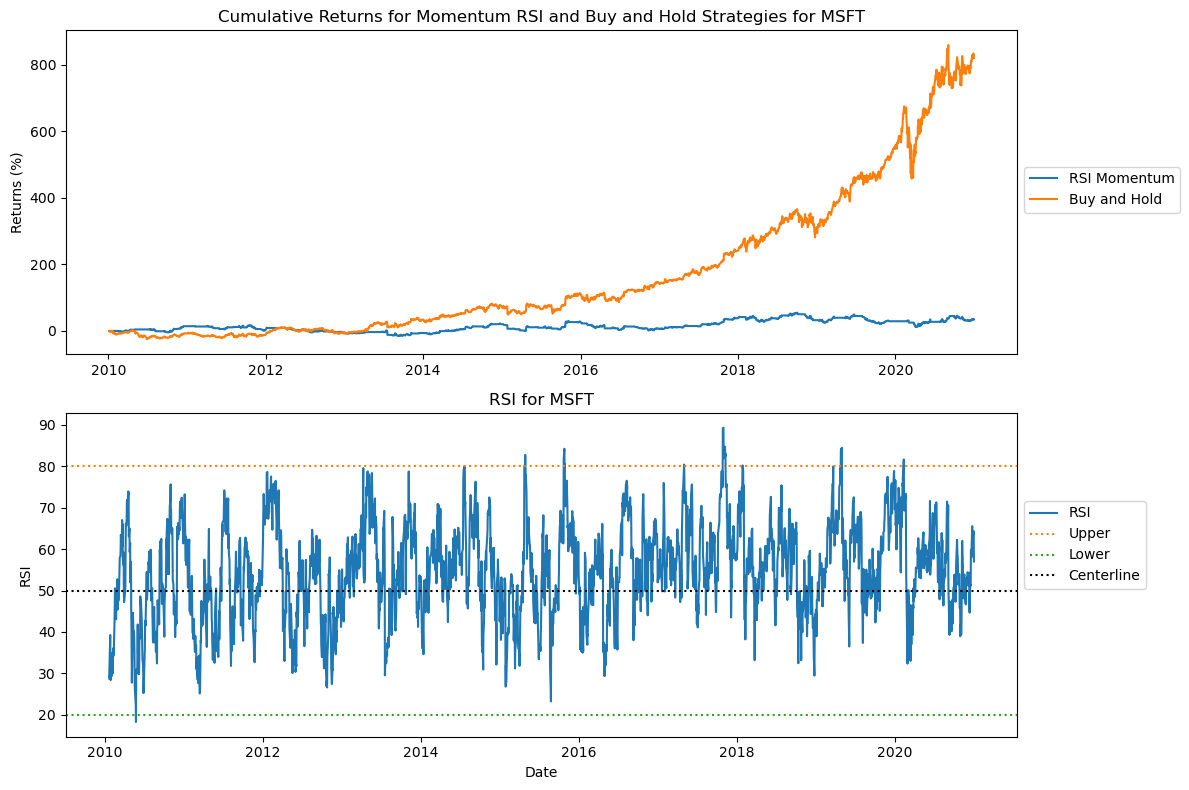

In [34]:
df_mom = RSIMomentumStrategy(data.copy())
# Plot results
fig, ax = plt.subplots(2, figsize=(12, 8))
ax[0].plot(df_mom['strat_cum_returns']*100, label='RSI Momentum')
ax[0].plot(df_mom['cum_returns']*100, label='Buy and Hold')
ax[0].set_ylabel('Returns (%)')
ax[0].set_title('Cumulative Returns for Momentum RSI and' +
  f' Buy and Hold Strategies for {ticker}')
ax[0].legend(bbox_to_anchor=[1, 0.6])
ax[1].plot(df_mom['RSI'], label='RSI')
ax[1].axhline(80, label='Upper', color=colors[1], linestyle=':')
ax[1].axhline(20, label='Lower', color=colors[2], linestyle=':')
ax[1].axhline(50, label='Centerline', color='k', linestyle=':')
ax[1].set_ylabel('RSI')
ax[1].set_xlabel('Date')
ax[1].set_title(f'RSI for {ticker}')
ax[1].legend(bbox_to_anchor=[1, 0.75])
plt.tight_layout()
plt.show()


In [35]:
stats_bh = getStratStats(df_mom['log_returns'])
stats_mom = getStratStats(df_mom['strat_log_returns'])
stats_df = pd.DataFrame()
stats_df = pd.concat([
  pd.DataFrame(stats_bh, index=['Buy and Hold']),
  pd.DataFrame(stats_mom, index=['RSI Momentum'])
])
stats_df

,tot_returns,annual_returns,annual_volatility,sharpe_ratio,max_drawdown,max_drawdown_duration
Buy and Hold,8.196294,0.223938,0.253990,0.802936,0.329050,652
RSI Momentum,0.344009,0.027292,0.153611,0.047472,0.328737,1114


In [36]:
# Trend Strategy
def RSITrendStrategy(data, P=14, sma1=5, sma2=20, 
  centerline=50, shorts=True):
  '''
  Buy when RSI crosses above centerline and when SMA1>SMA2.
  Sell if one of the conditions are no longer met.
  Short if RSI is below centerline and SMA1<SMA2
  '''
  df = calcRSI(data, P=P)
  df['SMA1'] = df['Close'].rolling(sma1).mean()
  df['SMA2'] = df['Close'].rolling(sma2).mean()
  df['position'] = np.nan
  df['position'] = np.where(
    (df['RSI']>centerline) & (df['SMA1']>df['SMA2']), 1,
    df['position'])
  df['position'] = np.where(
    (df['RSI']<centerline) & (df['SMA1']>df['SMA2']), 0,
    df['position'])
  df['position'] = np.where(
    (df['RSI']>centerline) & (df['SMA1']<df['SMA2']), 0, 
    df['position'])
  
  if shorts:
    df['position'] = np.where(
      (df['RSI']>centerline) & (df['SMA1']>df['SMA2']), -1,
      df['position'])
  else:
    df['position'] = np.where(
      (df['RSI']>centerline) & (df['SMA1']>df['SMA2']), 0,   
      df['position'])
  df['position'] = df['position'].ffill().fillna(0)
  return calcReturns(df)

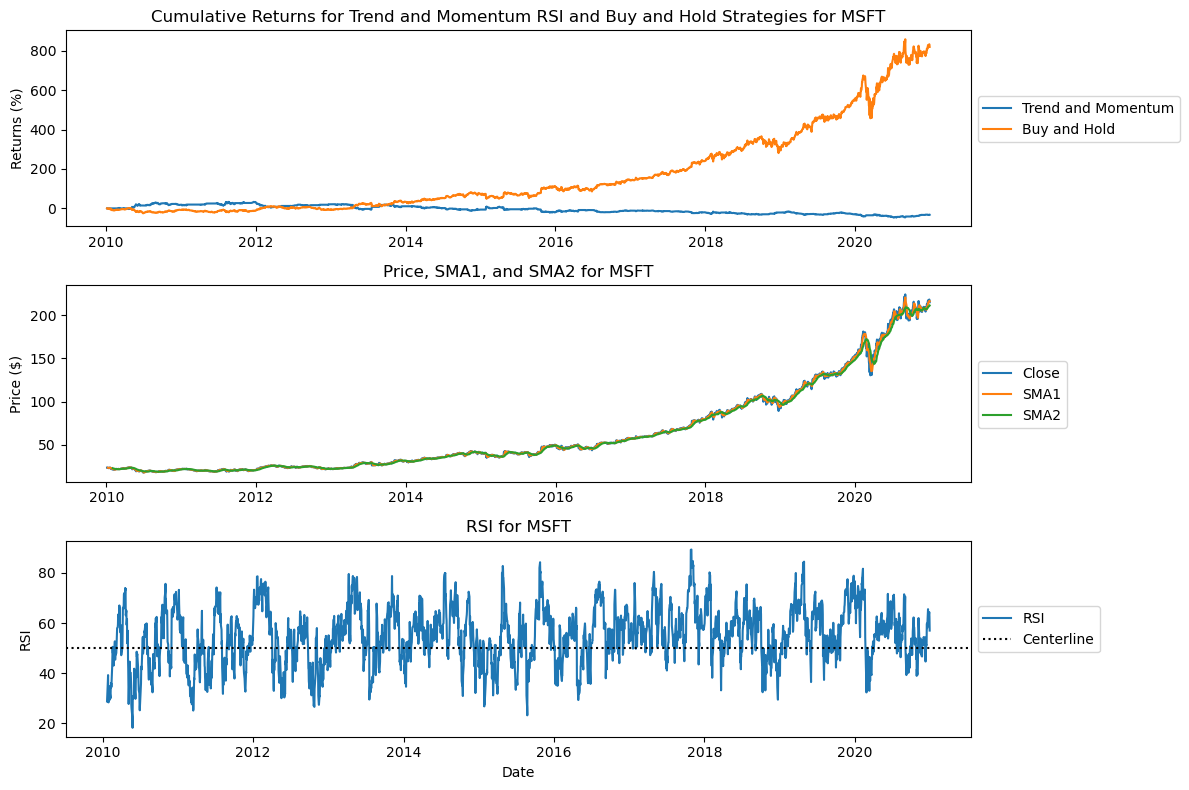

In [37]:
df_trend = RSITrendStrategy(data.copy())
# Plot results
fig, ax = plt.subplots(3, figsize=(12, 8))
ax[0].plot(df_trend['strat_cum_returns']*100, 
  label='Trend and Momentum')
ax[0].plot(df_trend['cum_returns']*100, label='Buy and Hold')
ax[0].set_ylabel('Returns (%)')
ax[0].set_title('Cumulative Returns for Trend and Momentum RSI and'+
 f' Buy and Hold Strategies for {ticker}')
ax[0].legend(bbox_to_anchor=[1, 0.7])
ax[1].plot(df_trend['Close'], label='Close')
ax[1].plot(df_trend['SMA1'], label='SMA1')
ax[1].plot(df_trend['SMA2'], label='SMA2')
ax[1].set_ylabel('Price ($)')
ax[1].set_title(f'Price, SMA1, and SMA2 for {ticker}')
ax[1].legend(bbox_to_anchor=[1, 0.65])
ax[2].plot(df_trend['RSI'], label='RSI')
ax[2].axhline(50, label='Centerline', color='k', linestyle=':')
ax[2].set_ylabel('RSI')
ax[2].set_xlabel('Date')
ax[2].set_title(f'RSI for {ticker}')
ax[2].legend(bbox_to_anchor=[1, 0.7])
plt.tight_layout()
plt.show()

In [38]:
stats_bh = getStratStats(df_trend['log_returns'])
stats_trend = getStratStats(df_trend['strat_log_returns'])
stats_df = pd.DataFrame()
stats_df = pd.concat([
  pd.DataFrame(stats_bh, index=['Buy and Hold']),
  pd.DataFrame(stats_trend, index=['RSI Trend'])
])
stats_df

,tot_returns,annual_returns,annual_volatility,sharpe_ratio,max_drawdown,max_drawdown_duration
Buy and Hold,8.196294,0.223938,0.253990,0.802936,0.329050,652
RSI Trend,-0.326143,-0.035311,0.180002,-0.307283,0.907261,3297


In [39]:
stats_df = pd.concat([
  pd.DataFrame(stats_bh, index=['Buy and Hold']),
  pd.DataFrame(stats_rev, index=['RSI Mean Reversion']),
  pd.DataFrame(stats_rsi2, index=['RSI(2)']),
  pd.DataFrame(stats_mom, index=['RSI Momentum']),
  pd.DataFrame(stats_trend, index=['RSI Trend'])
])
stats_df

,tot_returns,annual_returns,annual_volatility,sharpe_ratio,max_drawdown,max_drawdown_duration
Buy and Hold,8.196294,0.223938,0.253990,0.802936,0.329050,652
RSI Mean Reversion,0.036071,0.003232,0.125181,-0.133947,0.335529,2457
RSI(2),0.698529,0.049430,0.119153,0.246994,0.191461,1093
RSI Momentum,0.344009,0.027292,0.153611,0.047472,0.328737,1114
RSI Trend,-0.326143,-0.035311,0.180002,-0.307283,0.907261,3297


In [41]:
data

,Close
Date,
2010-01-04 00:00:00-05:00,23.389399
2010-01-05 00:00:00-05:00,23.396957
2010-01-06 00:00:00-05:00,23.253368
2010-01-07 00:00:00-05:00,23.011543
2010-01-08 00:00:00-05:00,23.170250
...,...
2020-12-23 00:00:00-05:00,214.455399
2020-12-24 00:00:00-05:00,216.134033
2020-12-28 00:00:00-05:00,218.278397
